<a href="https://colab.research.google.com/github/bdipesh3045/Data-Science-project-AI-Class-/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import random
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Deep Learning libraries
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.utils import to_categorical # needed for multi-class (26 signs, not just 2)
from sklearn.metrics import confusion_matrix, classification_report


In [13]:
train_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "datamunge/sign-language-mnist",
  "sign_mnist_train.csv"
)

test_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "datamunge/sign-language-mnist",
  "sign_mnist_test.csv"
)

# Check the shape (rows, columns)
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

# Preview first few rows
print("\nFirst 5 rows of training data:")
display(train_df.head())

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Training data shape: (27455, 785)
Test data shape: (7172, 785)

First 5 rows of training data:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


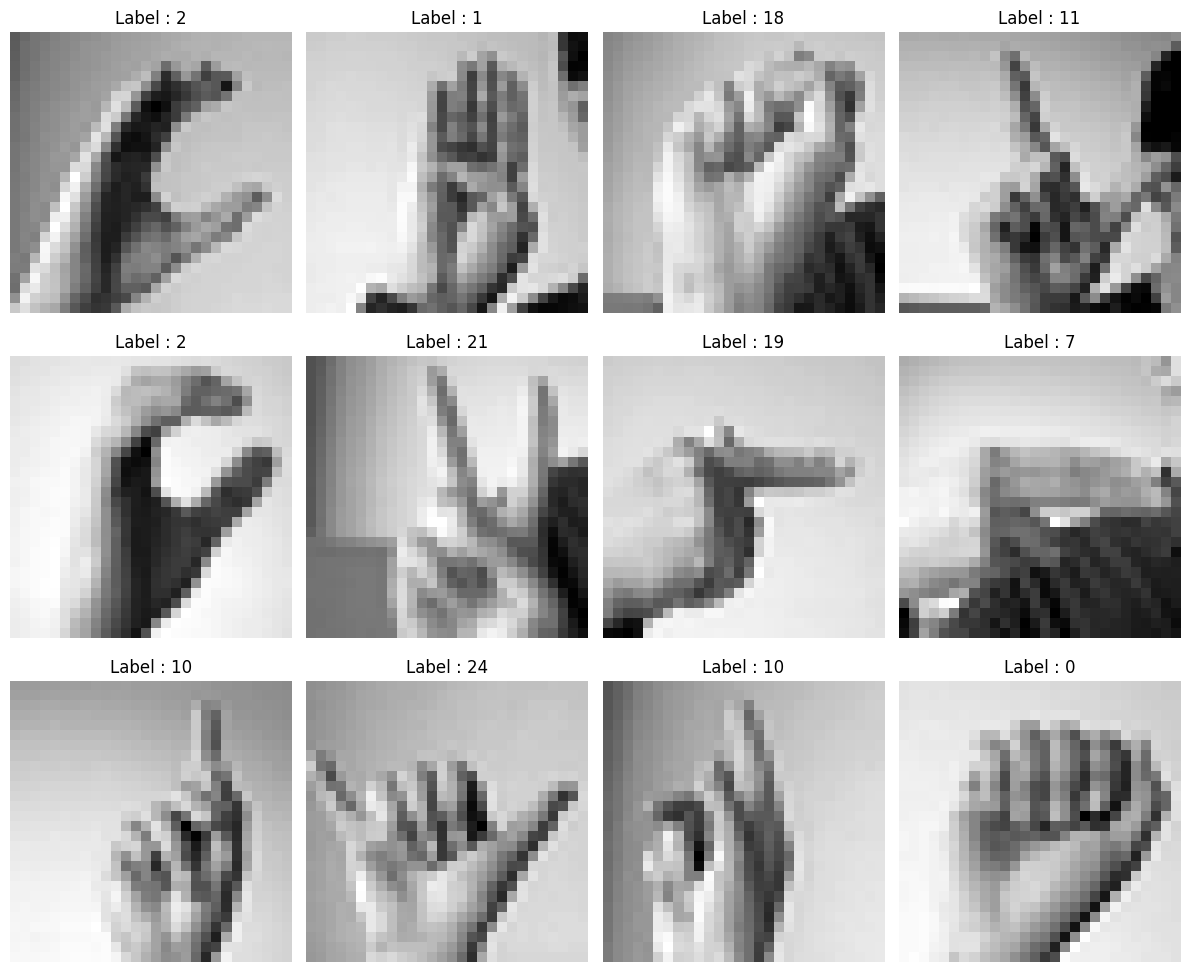

In [14]:
# Display Sample Images

plt.figure(figsize=(12,10))

for i in range(12):
    index = random.randint(0, len(train_df)-1)
    image = train_df.iloc[index,1:].values.reshape(28,28)
    label = train_df.iloc[index,0]

    plt.subplot(3,4,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label : {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Separate Features and Labels

X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (27455, 784)
Training Labels : (27455,)
Testing Images : (7172, 784)
Testing Labels : (7172,)


In [16]:
# Label Mapping

original_labels = sorted(np.unique(y_train))

label_mapping = {int(old): idx for idx, old in enumerate(original_labels)}
reverse_mapping = {idx: int(old) for old, idx in label_mapping.items()}

print(label_mapping)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23}


In [17]:
# Convert Labels

y_train = np.array([label_mapping[i] for i in y_train])
y_test = np.array([label_mapping[i] for i in y_test])

print(np.unique(y_train))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [18]:
# One Hot Encoding

num_classes = len(original_labels)

y_train = to_categorical(y_train,num_classes)
y_test = to_categorical(y_test,num_classes)

print(y_train.shape)
print(y_test.shape)

(27455, 24)
(7172, 24)
